In [1]:
from google.colab import files
uploaded = files.upload()

Saving animal_dataset.zip to animal_dataset.zip


In [2]:
import zipfile
zipfile.ZipFile("animal_dataset.zip", "r").extractall("dataset")


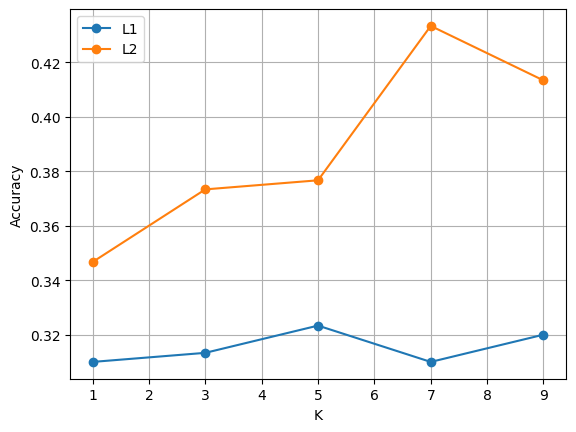

Image 1 Predicted Class: 1
Image 2 Predicted Class: 0
Image 3 Predicted Class: 0
Image 4 Predicted Class: 0
Image 5 Predicted Class: 0


In [7]:
import numpy as np
import cv2
import os
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

X = []
y = []
dataset_path = "dataset/animal_dataset"

for label, folder in enumerate(sorted(os.listdir(dataset_path))):
    folder_path = os.path.join(dataset_path, folder)
    if not os.path.isdir(folder_path):
        continue
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (32, 32))
        X.append(img.flatten())
        y.append(label)

X = np.array(X)
y = np.array(y)

def L1_distance(a, b):
    return np.sum(np.abs(a - b))

def L2_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

def knn_predict(X_train, y_train, x_test, k, dist):
    distances = []
    for i in range(len(X_train)):
        d = L1_distance(X_train[i], x_test) if dist=="L1" else L2_distance(X_train[i], x_test)
        distances.append((d, y_train[i]))
    distances.sort(key=lambda x: x[0])
    neighbors = [label for _, label in distances[:k]]
    return max(set(neighbors), key=neighbors.count)

K_values = [1, 3, 5, 7, 9]
acc_L1 = []
acc_L2 = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in K_values:
    fold_acc_L1 = []
    fold_acc_L2 = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        preds_L1 = [knn_predict(X_train, y_train, x, k, "L1") for x in X_test]
        preds_L2 = [knn_predict(X_train, y_train, x, k, "L2") for x in X_test]
        fold_acc_L1.append(np.mean(preds_L1 == y_test))
        fold_acc_L2.append(np.mean(preds_L2 == y_test))
    acc_L1.append(np.mean(fold_acc_L1))
    acc_L2.append(np.mean(fold_acc_L2))

plt.plot(K_values, acc_L1, marker='o', label="L1")
plt.plot(K_values, acc_L2, marker='o', label="L2")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

test_images = X[:5]
for i, img in enumerate(test_images):
    pred = knn_predict(X, y, img, k=3, dist="L2")
    print("Image", i+1, "Predicted Class:", pred)


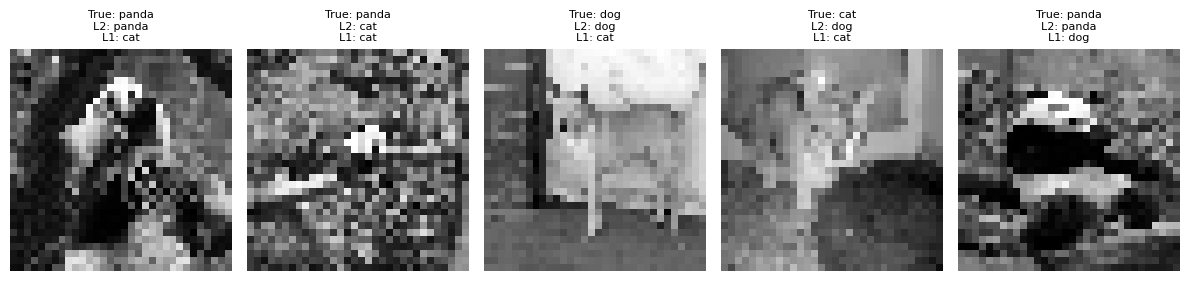

In [8]:
from sklearn.model_selection import train_test_split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

# Select 5 samples
top5_test_imgs = X_test[:5]
top5_true_labels = y_test[:5]

k = 5

# Predictions
top5_preds_L1 = [knn_predict(X_train, y_train, x, k, "L1") for x in top5_test_imgs]
top5_preds_L2 = [knn_predict(X_train, y_train, x, k, "L2") for x in top5_test_imgs]

# class names based on folder order
class_names = {i: name for i, name in enumerate(sorted(os.listdir(dataset_path)))}

# Plot results
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(top5_test_imgs[i].reshape(32, 32), cmap='gray')
    plt.title(
        f"True: {class_names[top5_true_labels[i]]}\n"
        f"L2: {class_names[top5_preds_L2[i]]}\n"
        f"L1: {class_names[top5_preds_L1[i]]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()
